In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from stage_escape import (
    BrownianMotion,
    Surface,
    Escape,
    EquivalentNarrowEscape
)
from stage_escape.visualization import plot_brownian_path
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

plt.rcParams.update(
    {
        "figure.figsize": (8.0, 4.8),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "legend.frameon": False,
    }
)

SAVE_FIGURES = False

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró pyproject.toml. Ejecuta el notebook dentro del repositorio."
    )

REPO_ROOT = find_repo_root()
FIGURE_DIR = REPO_ROOT / "artifacts" / "figures" / "notebook_00"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def finish_figure(fig, name: str) -> None:
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / f"{name}.png", bbox_inches="tight")
        fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.show()

## 2 Dimensions

In [24]:
D = 0.40
N_STEPS_2D = 1_000_000

def run_one_simulation(seed: int, epsilon: float = 0.0):
    surface = Surface(
        name="Half-plane",
        functions=[
            lambda x: x[0]
        ]
    )

    escape1 = Escape(
        conditions=[
            lambda x: x[0] >= 0.0,
            lambda x: np.abs(x[1]) <= epsilon
        ]
    )

    escape2 = Escape(
        conditions=[
            lambda x: x[0] ** 2 + x[1] ** 2 >= epsilon
        ]
    )


    motion2d = BrownianMotion(
        deposition_stride=2,
        delta_t=epsilon / 100_000,
        dimension=2,
        D=D,
        initial_position=np.array([-epsilon, 0.0]),
        seed=seed
    )

    simulation = EquivalentNarrowEscape(
        brownian_motion=motion2d,
        surface=surface,
        escapes=[escape1, escape2]
    )

    result = simulation.run(
        max_steps=N_STEPS_2D,
        reset=True
    )

    return result

  0%|          | 0/50 [00:00<?, ?it/s]

Running simulations for epsilon = 0.500


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.401


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

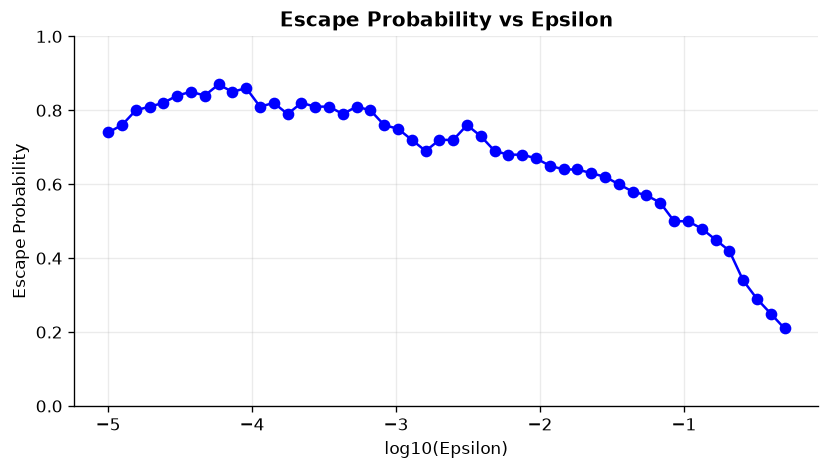

In [25]:
epsilon_axis = np.logspace(np.log10(0.5), np.log10(1e-5), 50)
probability_axis = []

for epsilon in tqdm(epsilon_axis):
    print(f"Running simulations for epsilon = {epsilon:.3f}")

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(seed=i, epsilon=epsilon) for i in tqdm(range(100))
    )

    total_count = 0
    escape_count = 0
    for result in results:
        if result.escaped:
            total_count += 1
            if result.escape_index == 0:
                escape_count += 1

    escape_probability = escape_count / total_count if total_count > 0 else 0.0
    probability_axis.append(escape_probability)

plt.figure(figsize=(8, 4))
plt.plot(np.log10(epsilon_axis), probability_axis, marker='o', linestyle='-', color='blue')
plt.xlabel('log10(Epsilon)')
plt.ylabel('Escape Probability')
plt.title('Escape Probability vs Epsilon')
plt.grid(True)
plt.ylim(0, 1)

if SAVE_FIGURES:
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.png", bbox_inches="tight")
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.pdf", bbox_inches="tight")
plt.show()         

In [2]:
D = 0.40
DELTA_T = 1.0e-5
N_STEPS_2D = 1_000_000

def run_one_simulation(seed: int, epsilon: float = 0.0):
    surface = Surface(
        name="Half-plane",
        functions=[
            lambda x: x[0]
        ]
    )

    escape1 = Escape(
        conditions=[
            lambda x: x[0] >= 0.0,
            lambda x: np.abs(x[1]) <= epsilon
        ]
    )

    escape2 = Escape(
        conditions=[
            lambda x: x[0] ** 2 + x[1] ** 2 >= 9 * epsilon ** 2
        ]
    )


    motion2d = BrownianMotion(
        deposition_stride=2,
        delta_t=epsilon / 10_000,
        dimension=2,
        D=D,
        initial_position=np.array([-epsilon, 0.0]),
        seed=seed
    )

    simulation = EquivalentNarrowEscape(
        brownian_motion=motion2d,
        surface=surface,
        escapes=[escape1, escape2]
    )

    result = simulation.run(
        max_steps=N_STEPS_2D,
        reset=True
    )

    return result

  0%|          | 0/50 [00:00<?, ?it/s]

Running simulations for epsilon = 0.500


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.401


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

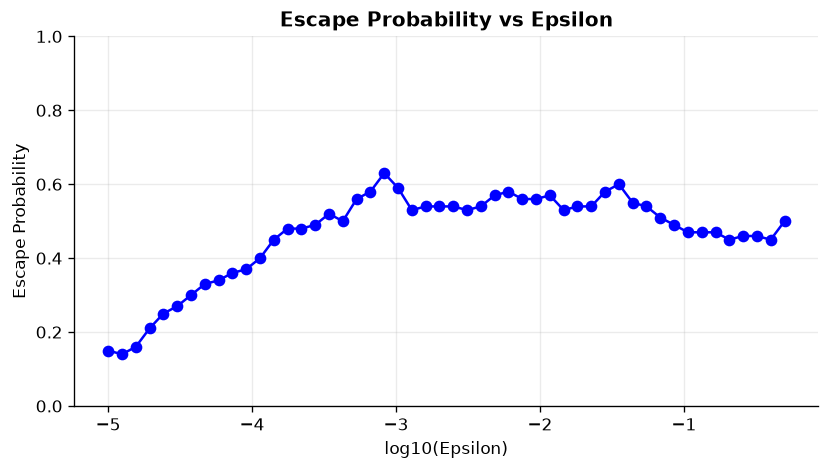

In [3]:
epsilon_axis = np.logspace(np.log10(0.5), np.log10(1e-5), 50)
probability_axis = []

for epsilon in tqdm(epsilon_axis):
    print(f"Running simulations for epsilon = {epsilon:.3f}")

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(seed=i, epsilon=epsilon) for i in tqdm(range(100))
    )

    total_count = 0
    escape_count = 0
    for result in results:
        if result.escaped:
            total_count += 1
            if result.escape_index == 0:
                escape_count += 1

    escape_probability = escape_count / total_count if total_count > 0 else 0.0
    probability_axis.append(escape_probability)

plt.figure(figsize=(8, 4))
plt.plot(np.log10(epsilon_axis), probability_axis, marker='o', linestyle='-', color='blue')
plt.xlabel('log10(Epsilon)')
plt.ylabel('Escape Probability')
plt.title('Escape Probability vs Epsilon')
plt.grid(True)
plt.ylim(0, 1)

if SAVE_FIGURES:
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.png", bbox_inches="tight")
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.pdf", bbox_inches="tight")
plt.show()         

In [ ]:
D = 0.40
DELTA_T = 1.0e-5
N_STEPS_2D = 1_000_000

def run_one_simulation(seed: int, epsilon: float = 0.0):
    surface = Surface(
        name="Half-plane",
        functions=[
            lambda x: x[0]
        ]
    )

    escape1 = Escape(
        conditions=[
            lambda x: x[0] >= 0.0,
            lambda x: np.abs(x[1]) <= epsilon
        ]
    )

    escape2 = Escape(
        conditions=[
            lambda x: x[0] ** 2 + x[1] ** 2 >= 25 * epsilon ** 2
        ]
    )


    motion2d = BrownianMotion(
        deposition_stride=2,
        delta_t=epsilon / 10_000,
        dimension=2,
        D=D,
        initial_position=np.array([-epsilon, 0.0]),
        seed=seed
    )

    simulation = EquivalentNarrowEscape(
        brownian_motion=motion2d,
        surface=surface,
        escapes=[escape1, escape2]
    )

    result = simulation.run(
        max_steps=N_STEPS_2D,
        reset=True
    )

    return result

  0%|          | 0/50 [00:00<?, ?it/s]

Running simulations for epsilon = 0.500


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.401


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

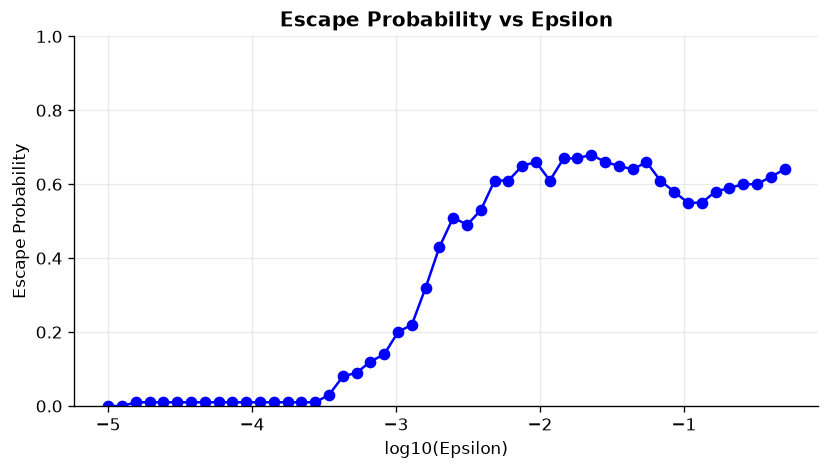

In [5]:
epsilon_axis = np.logspace(np.log10(0.5), np.log10(1e-5), 50)
probability_axis = []

for epsilon in tqdm(epsilon_axis):
    print(f"Running simulations for epsilon = {epsilon:.3f}")

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(seed=i, epsilon=epsilon) for i in tqdm(range(100))
    )

    total_count = 0
    escape_count = 0
    for result in results:
        if result.escaped:
            total_count += 1
            if result.escape_index == 0:
                escape_count += 1

    escape_probability = escape_count / total_count if total_count > 0 else 0.0
    probability_axis.append(escape_probability)

plt.figure(figsize=(8, 4))
plt.plot(np.log10(epsilon_axis), probability_axis, marker='o', linestyle='-', color='blue')
plt.xlabel('log10(Epsilon)')
plt.ylabel('Escape Probability')
plt.title('Escape Probability vs Epsilon')
plt.grid(True)
plt.ylim(0, 1)

if SAVE_FIGURES:
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.png", bbox_inches="tight")
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.pdf", bbox_inches="tight")
plt.show()         

## 3 dimensions

In [4]:
D = 0.40
DELTA_T = 1.0e-5
N_STEPS_2D = 1_000_000

def run_one_simulation(seed: int, epsilon: float = 0.0):
    surface = Surface(
        name="Half-space",
        functions=[
            lambda x: x[0]
        ]
    )

    escape1 = Escape(
        conditions=[
            lambda x: x[0] >= 0.0,
            lambda x: x[1] ** 2 + x[2] ** 2 <= epsilon ** 2
        ]
    )

    escape2 = Escape(
        conditions=[
            lambda x: x[0] ** 2 + x[1] ** 2 + x[2] ** 2 >= epsilon
        ]
    )


    motion2d = BrownianMotion(
        deposition_stride=2,
        delta_t=epsilon / 100_000,
        dimension=3,
        D=D,
        initial_position=np.array([-epsilon, 0.0, 0.0]),
        seed=seed
    )

    simulation = EquivalentNarrowEscape(
        brownian_motion=motion2d,
        surface=surface,
        escapes=[escape1, escape2]
    )

    result = simulation.run(
        max_steps=N_STEPS_2D,
        reset=True
    )

    return result

  0%|          | 0/50 [00:00<?, ?it/s]

Running simulations for epsilon = 0.500


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.401


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

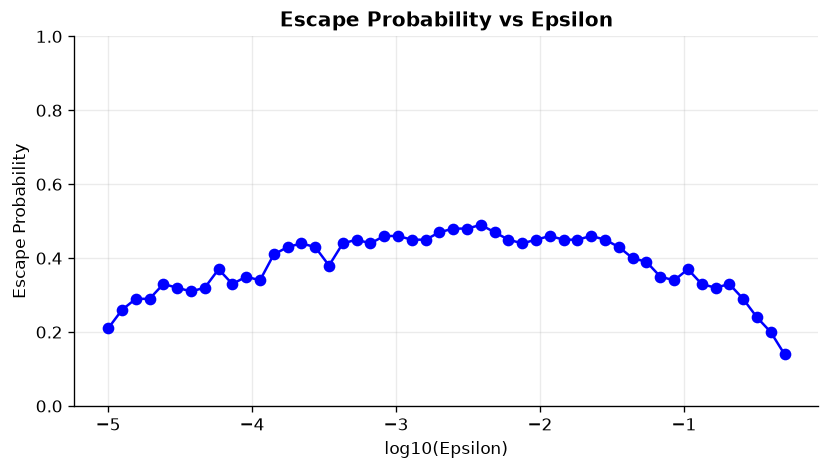

In [5]:
epsilon_axis = np.logspace(np.log10(0.5), np.log10(1e-5), 50)
probability_axis = []

for epsilon in tqdm(epsilon_axis):
    print(f"Running simulations for epsilon = {epsilon:.3f}")

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(seed=i, epsilon=epsilon) for i in tqdm(range(100))
    )

    total_count = 0
    escape_count = 0
    for result in results:
        if result.escaped:
            total_count += 1
            if result.escape_index == 0:
                escape_count += 1

    escape_probability = escape_count / total_count if total_count > 0 else 0.0
    probability_axis.append(escape_probability)

plt.figure(figsize=(8, 4))
plt.plot(np.log10(epsilon_axis), probability_axis, marker='o', linestyle='-', color='blue')
plt.xlabel('log10(Epsilon)')
plt.ylabel('Escape Probability')
plt.title('Escape Probability vs Epsilon')
plt.grid(True)
plt.ylim(0, 1)

if SAVE_FIGURES:
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.png", bbox_inches="tight")
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.pdf", bbox_inches="tight")
plt.show()   

In [ ]:
D = 0.40
DELTA_T = 1.0e-5
N_STEPS_2D = 1_000_000

def run_one_simulation(seed: int, epsilon: float = 0.0):
    surface = Surface(
        name="Half-space",
        functions=[
            lambda x: x[0]
        ]
    )

    escape1 = Escape(
        conditions=[
            lambda x: x[0] >= 0.0,
            lambda x: x[1] ** 2 + x[2] ** 2 <= epsilon ** 2
        ]
    )

    escape2 = Escape(
        conditions=[
            lambda x: x[0] ** 2 + x[1] ** 2 + x[2] ** 2 >= 9 * epsilon ** 2
        ]
    )


    motion2d = BrownianMotion(
        deposition_stride=2,
        delta_t=epsilon / 100_000,
        dimension=3,
        D=D,
        initial_position=np.array([-epsilon, 0.0, 0.0]),
        seed=seed
    )

    simulation = EquivalentNarrowEscape(
        brownian_motion=motion2d,
        surface=surface,
        escapes=[escape1, escape2]
    )

    result = simulation.run(
        max_steps=N_STEPS_2D,
        reset=True
    )

    return result

  0%|          | 0/50 [00:00<?, ?it/s]

Running simulations for epsilon = 0.500


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.401


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

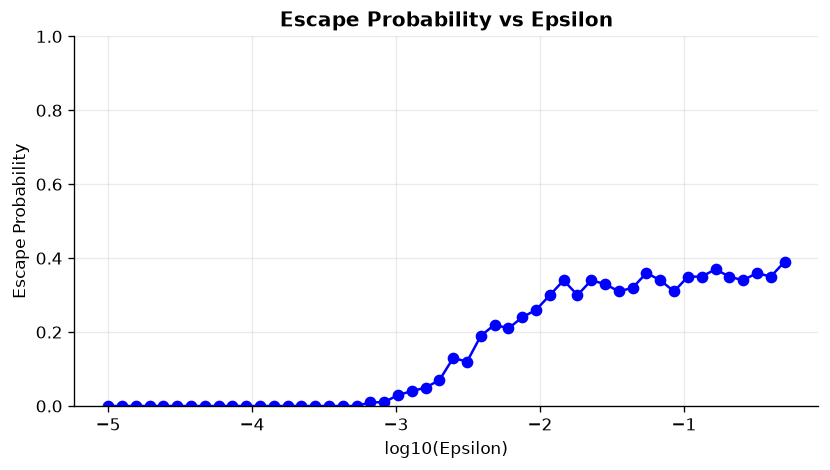

In [11]:
epsilon_axis = np.logspace(np.log10(0.5), np.log10(1e-5), 50)
probability_axis = []

for epsilon in tqdm(epsilon_axis):
    print(f"Running simulations for epsilon = {epsilon:.3f}")

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(seed=i, epsilon=epsilon) for i in tqdm(range(100))
    )

    total_count = 0
    escape_count = 0
    for result in results:
        if result.escaped:
            total_count += 1
            if result.escape_index == 0:
                escape_count += 1

    escape_probability = escape_count / total_count if total_count > 0 else 0.0
    probability_axis.append(escape_probability)

plt.figure(figsize=(8, 4))
plt.plot(np.log10(epsilon_axis), probability_axis, marker='o', linestyle='-', color='blue')
plt.xlabel('log10(Epsilon)')
plt.ylabel('Escape Probability')
plt.title('Escape Probability vs Epsilon')
plt.grid(True)
plt.ylim(0, 1)

if SAVE_FIGURES:
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.png", bbox_inches="tight")
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.pdf", bbox_inches="tight")
plt.show()

In [12]:
D = 0.40
DELTA_T = 1.0e-5
N_STEPS_2D = 1_000_000

def run_one_simulation(seed: int, epsilon: float = 0.0):
    surface = Surface(
        name="Half-space",
        functions=[
            lambda x: x[0]
        ]
    )

    escape1 = Escape(
        conditions=[
            lambda x: x[0] >= 0.0,
            lambda x: x[1] ** 2 + x[2] ** 2 <= epsilon ** 2
        ]
    )

    escape2 = Escape(
        conditions=[
            lambda x: x[0] ** 2 + x[1] ** 2 + x[2] ** 2 >= 25 * epsilon ** 2
        ]
    )


    motion2d = BrownianMotion(
        deposition_stride=2,
        delta_t=DELTA_T,
        dimension=3,
        D=D,
        initial_position=np.array([-epsilon, 0.0, 0.0]),
        seed=seed
    )

    simulation = EquivalentNarrowEscape(
        brownian_motion=motion2d,
        surface=surface,
        escapes=[escape1, escape2]
    )

    result = simulation.run(
        max_steps=N_STEPS_2D,
        reset=True
    )

    return result

  0%|          | 0/50 [00:00<?, ?it/s]

Running simulations for epsilon = 0.500


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.401


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

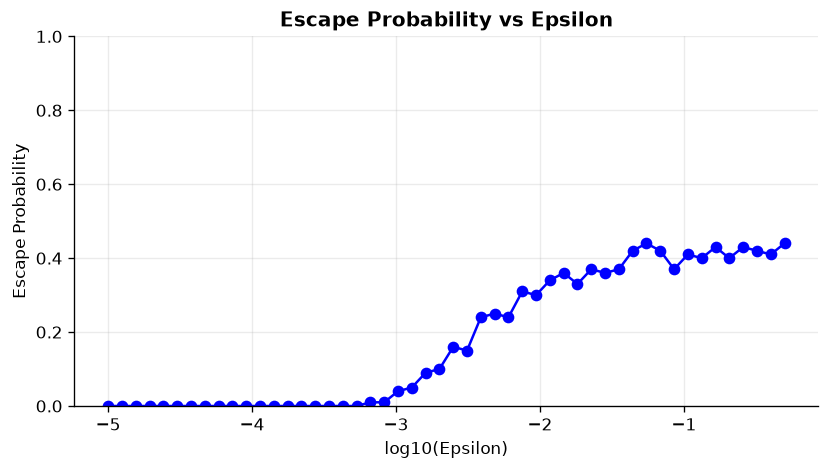

In [13]:
epsilon_axis = np.logspace(np.log10(0.5), np.log10(1e-5), 50)
probability_axis = []

for epsilon in tqdm(epsilon_axis):
    print(f"Running simulations for epsilon = {epsilon:.3f}")

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(seed=i, epsilon=epsilon) for i in tqdm(range(100))
    )

    total_count = 0
    escape_count = 0
    for result in results:
        if result.escaped:
            total_count += 1
            if result.escape_index == 0:
                escape_count += 1

    escape_probability = escape_count / total_count if total_count > 0 else 0.0
    probability_axis.append(escape_probability)

plt.figure(figsize=(8, 4))
plt.plot(np.log10(epsilon_axis), probability_axis, marker='o', linestyle='-', color='blue')
plt.xlabel('log10(Epsilon)')
plt.ylabel('Escape Probability')
plt.title('Escape Probability vs Epsilon')
plt.grid(True)
plt.ylim(0, 1)

if SAVE_FIGURES:
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.png", bbox_inches="tight")
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.pdf", bbox_inches="tight")
plt.show()

## 4 dimensions

In [6]:
D = 0.40
DELTA_T = 1.0e-5
N_STEPS_2D = 1_000_000

def run_one_simulation(seed: int, epsilon: float = 0.0):
    surface = Surface(
        name="Half-space",
        functions=[
            lambda x: x[0]
        ]
    )

    escape1 = Escape(
        conditions=[
            lambda x: x[0] >= 0.0,
            lambda x: x[1] ** 2 + x[2] ** 2 + x[3] ** 2 <= epsilon ** 2
        ]
    )

    escape2 = Escape(
        conditions=[
            lambda x: x[0] ** 2 + x[1] ** 2 + x[2] ** 2 + x[3] ** 2 >= epsilon
        ]
    )


    motion2d = BrownianMotion(
        deposition_stride=2,
        delta_t=epsilon / 100_000,
        dimension=4,
        D=D,
        initial_position=np.array([-epsilon, 0.0, 0.0, 0.0]),
        seed=seed
    )

    simulation = EquivalentNarrowEscape(
        brownian_motion=motion2d,
        surface=surface,
        escapes=[escape1, escape2]
    )

    result = simulation.run(
        max_steps=N_STEPS_2D,
        reset=True
    )

    return result

  0%|          | 0/50 [00:00<?, ?it/s]

Running simulations for epsilon = 0.500


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.401


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

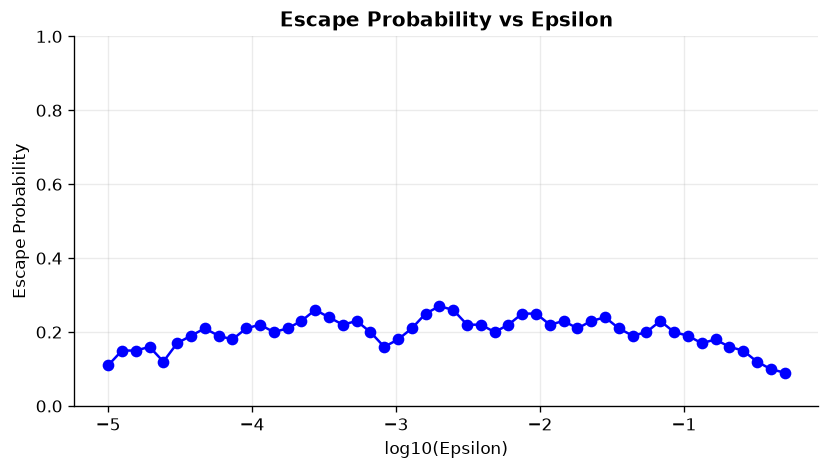

In [7]:
epsilon_axis = np.logspace(np.log10(0.5), np.log10(1e-5), 50)
probability_axis = []

for epsilon in tqdm(epsilon_axis):
    print(f"Running simulations for epsilon = {epsilon:.3f}")

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(seed=i, epsilon=epsilon) for i in tqdm(range(100))
    )

    total_count = 0
    escape_count = 0
    for result in results:
        if result.escaped:
            total_count += 1
            if result.escape_index == 0:
                escape_count += 1

    escape_probability = escape_count / total_count if total_count > 0 else 0.0
    probability_axis.append(escape_probability)

plt.figure(figsize=(8, 4))
plt.plot(np.log10(epsilon_axis), probability_axis, marker='o', linestyle='-', color='blue')
plt.xlabel('log10(Epsilon)')
plt.ylabel('Escape Probability')
plt.title('Escape Probability vs Epsilon')
plt.grid(True)
plt.ylim(0, 1)

if SAVE_FIGURES:
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.png", bbox_inches="tight")
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.pdf", bbox_inches="tight")
plt.show()

In [8]:
D = 0.40
DELTA_T = 1.0e-5
N_STEPS_2D = 1_000_000

def run_one_simulation(seed: int, epsilon: float = 0.0):
    surface = Surface(
        name="Half-space",
        functions=[
            lambda x: x[0]
        ]
    )

    escape1 = Escape(
        conditions=[
            lambda x: x[0] >= 0.0,
            lambda x: x[1] ** 2 + x[2] ** 2 + x[3] ** 2 <= epsilon ** 2
        ]
    )

    escape2 = Escape(
        conditions=[
            lambda x: x[0] ** 2 + x[1] ** 2 + x[2] ** 2 + x[3] ** 2 >= 9 * epsilon ** 2
        ]
    )


    motion2d = BrownianMotion(
        deposition_stride=2,
        delta_t=epsilon / 100_000,
        dimension=4,
        D=D,
        initial_position=np.array([-epsilon, 0.0, 0.0, 0.0]),
        seed=seed
    )

    simulation = EquivalentNarrowEscape(
        brownian_motion=motion2d,
        surface=surface,
        escapes=[escape1, escape2]
    )

    result = simulation.run(
        max_steps=N_STEPS_2D,
        reset=True
    )

    return result

  0%|          | 0/50 [00:00<?, ?it/s]

Running simulations for epsilon = 0.500


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.401


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

Running simulations for epsilon = 0.000


  0%|          | 0/100 [00:00<?, ?it/s]

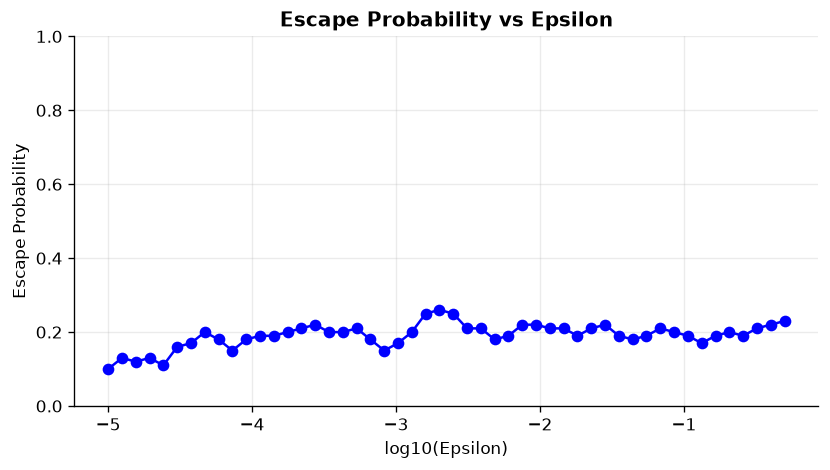

In [9]:
epsilon_axis = np.logspace(np.log10(0.5), np.log10(1e-5), 50)
probability_axis = []

for epsilon in tqdm(epsilon_axis):
    print(f"Running simulations for epsilon = {epsilon:.3f}")

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(seed=i, epsilon=epsilon) for i in tqdm(range(100))
    )

    total_count = 0
    escape_count = 0
    for result in results:
        if result.escaped:
            total_count += 1
            if result.escape_index == 0:
                escape_count += 1

    escape_probability = escape_count / total_count if total_count > 0 else 0.0
    probability_axis.append(escape_probability)

plt.figure(figsize=(8, 4))
plt.plot(np.log10(epsilon_axis), probability_axis, marker='o', linestyle='-', color='blue')
plt.xlabel('log10(Epsilon)')
plt.ylabel('Escape Probability')
plt.title('Escape Probability vs Epsilon')
plt.grid(True)
plt.ylim(0, 1)

if SAVE_FIGURES:
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.png", bbox_inches="tight")
    plt.savefig(FIGURE_DIR / "escape_probability_vs_epsilon.pdf", bbox_inches="tight")
plt.show()